# Notebook 4: Traditional ML Models
## Hyperspectral Data Science for Corn

**Objectives:**
- Load PCA-reduced datasets
- Train multiple ML models
- Compare model performance
- Analyze feature importance
- Save best model and results

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load PCA-Reduced Data

In [2]:
# Load PCA datasets
X_train = pd.read_csv('../data/X_train_pca.csv')
X_test = pd.read_csv('../data/X_test_pca.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

print("Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data loaded successfully!
X_train shape: (400, 3)
X_test shape: (100, 3)
y_train shape: (400,)
y_test shape: (100,)


## 2. Initialize Models

In [3]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, max_depth=6, learning_rate=0.1),
    'SVR': SVR(kernel='rbf', C=100, gamma='scale')
}

print("Models initialized:")
for name in models.keys():
    print(f"  - {name}")

Models initialized:
  - Linear Regression
  - Decision Tree
  - Random Forest
  - XGBoost
  - SVR


## 3. Train and Evaluate Models

In [4]:
# Store results
results = []
predictions = {}

print("Training models...\n")
for name, model in models.items():
    print(f"Training {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Store predictions
    predictions[name] = {'train': y_train_pred, 'test': y_test_pred}
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Store results
    results.append({
        'Model': name,
        'Train_RMSE': train_rmse,
        'Train_MAE': train_mae,
        'Train_R2': train_r2,
        'Test_RMSE': test_rmse,
        'Test_MAE': test_mae,
        'Test_R2': test_r2
    })
    
    print(f"  Test R²: {test_r2:.4f}, Test RMSE: {test_rmse:.2f}\n")

print("✓ All models trained!")

Training models...

Training Linear Regression...
  Test R²: 0.4726, Test RMSE: 12141.97

Training Decision Tree...
  Test R²: 0.9433, Test RMSE: 3980.12

Training Random Forest...
  Test R²: 0.9495, Test RMSE: 3758.31

Training XGBoost...
  Test R²: 0.9314, Test RMSE: 4380.58

Training SVR...
  Test R²: -0.0376, Test RMSE: 17031.07

✓ All models trained!


## 4. Results Summary

In [5]:
# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test_R2', ascending=False)

print("="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

MODEL COMPARISON RESULTS
            Model   Train_RMSE   Train_MAE  Train_R2    Test_RMSE    Test_MAE   Test_R2
    Random Forest  3531.647630 1016.196624  0.913234  3758.309770 1869.779839  0.949470
    Decision Tree   302.283765  148.532381  0.999364  3980.118867 1688.033333  0.943329
          XGBoost   514.381637  337.077545  0.998159  4380.576903 1996.279663  0.931352
Linear Regression  9655.911949 4248.695371  0.351391 12141.973349 4918.126946  0.472594
              SVR 12152.649289 2912.753586 -0.027396 17031.067889 4170.638142 -0.037649


## 5. Performance Comparison Visualization

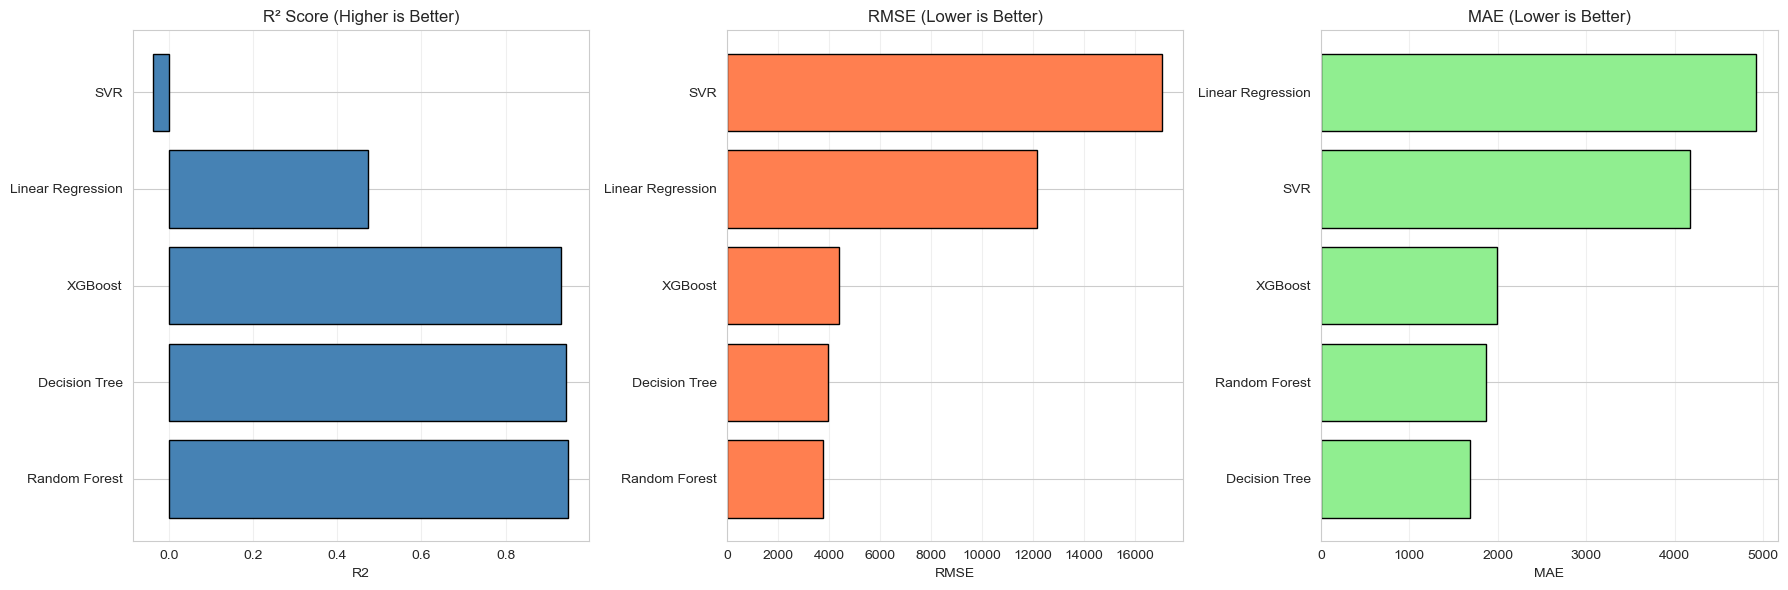

In [6]:
# Bar plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['Test_R2', 'Test_RMSE', 'Test_MAE']
titles = ['R² Score (Higher is Better)', 'RMSE (Lower is Better)', 'MAE (Lower is Better)']
colors = ['steelblue', 'coral', 'lightgreen']

for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    sorted_df = results_df.sort_values(metric, ascending=(metric != 'Test_R2'))
    axes[i].barh(sorted_df['Model'], sorted_df[metric], color=color, edgecolor='black')
    axes[i].set_xlabel(metric.replace('Test_', '').replace('_', ' '))
    axes[i].set_title(title)
    axes[i].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Prediction vs Actual for Best Model

In [7]:
# Get best model
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['Test_R2']

print(f"Best Model: {best_model_name}")
print(f"Test R² Score: {best_r2:.4f}")

Best Model: Random Forest
Test R² Score: 0.9495


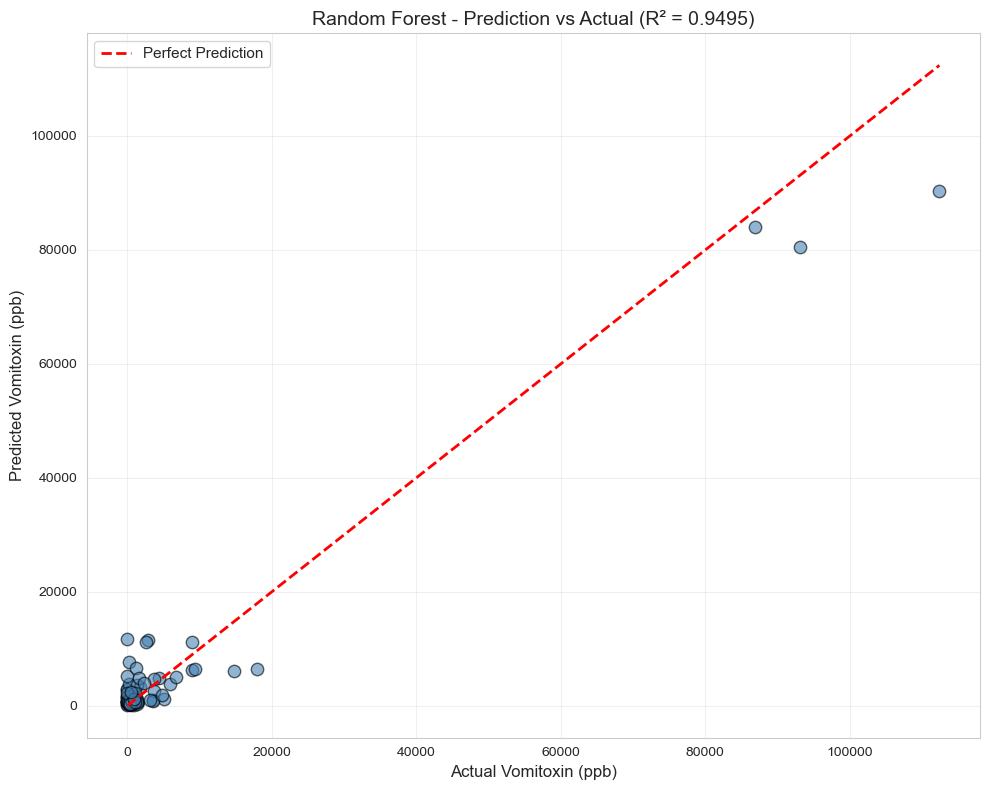

In [8]:
# Plot predictions for best model
y_test_pred_best = predictions[best_model_name]['test']

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_test_pred_best, alpha=0.6, edgecolors='black', s=80, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Vomitoxin (ppb)', fontsize=12)
plt.ylabel('Predicted Vomitoxin (ppb)', fontsize=12)
plt.title(f'{best_model_name} - Prediction vs Actual (R² = {best_r2:.4f})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/best_model_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Feature Importance Analysis

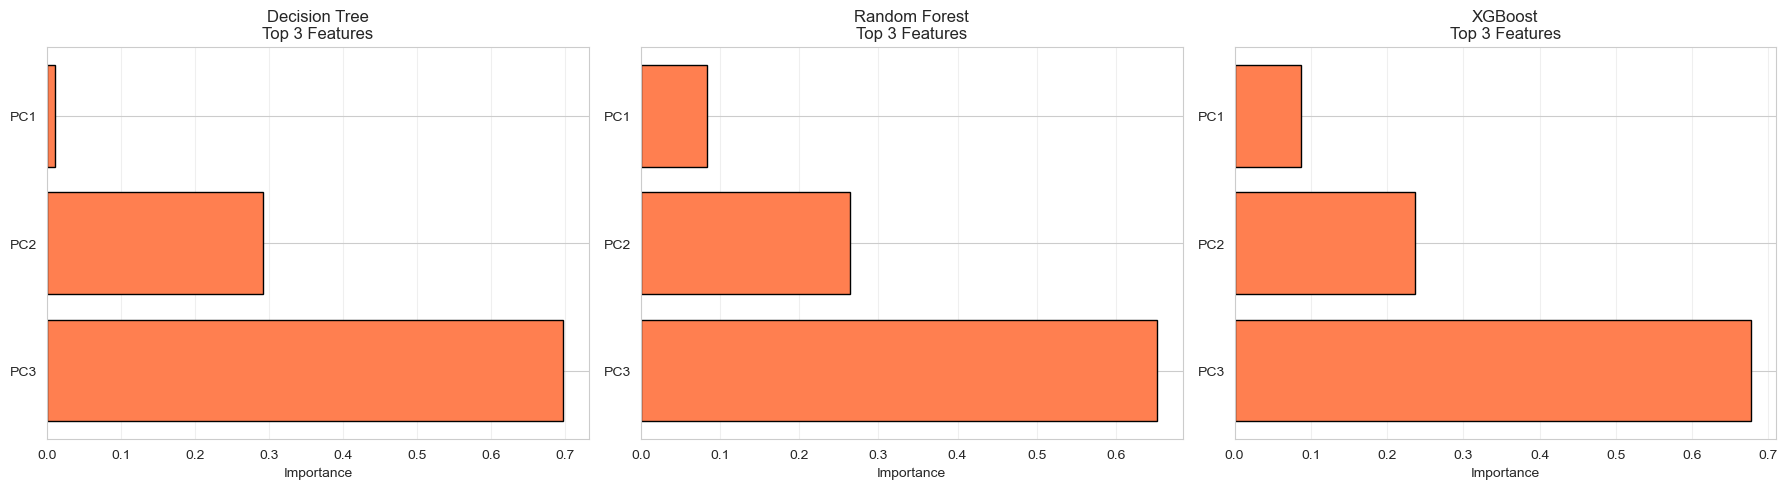

In [9]:
# Feature importance for tree-based models
tree_models = ['Decision Tree', 'Random Forest', 'XGBoost']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, model_name in enumerate(tree_models):
    model = models[model_name]
    importances = model.feature_importances_
    n_features = min(10, len(importances))
    top_indices = np.argsort(importances)[-n_features:][::-1]
    
    axes[i].barh(range(n_features), importances[top_indices], color='coral', edgecolor='black')
    axes[i].set_yticks(range(n_features))
    axes[i].set_yticklabels([X_train.columns[idx] for idx in top_indices])
    axes[i].set_xlabel('Importance')
    axes[i].set_title(f'{model_name}\nTop {n_features} Features')
    axes[i].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Residual Analysis for Best Model

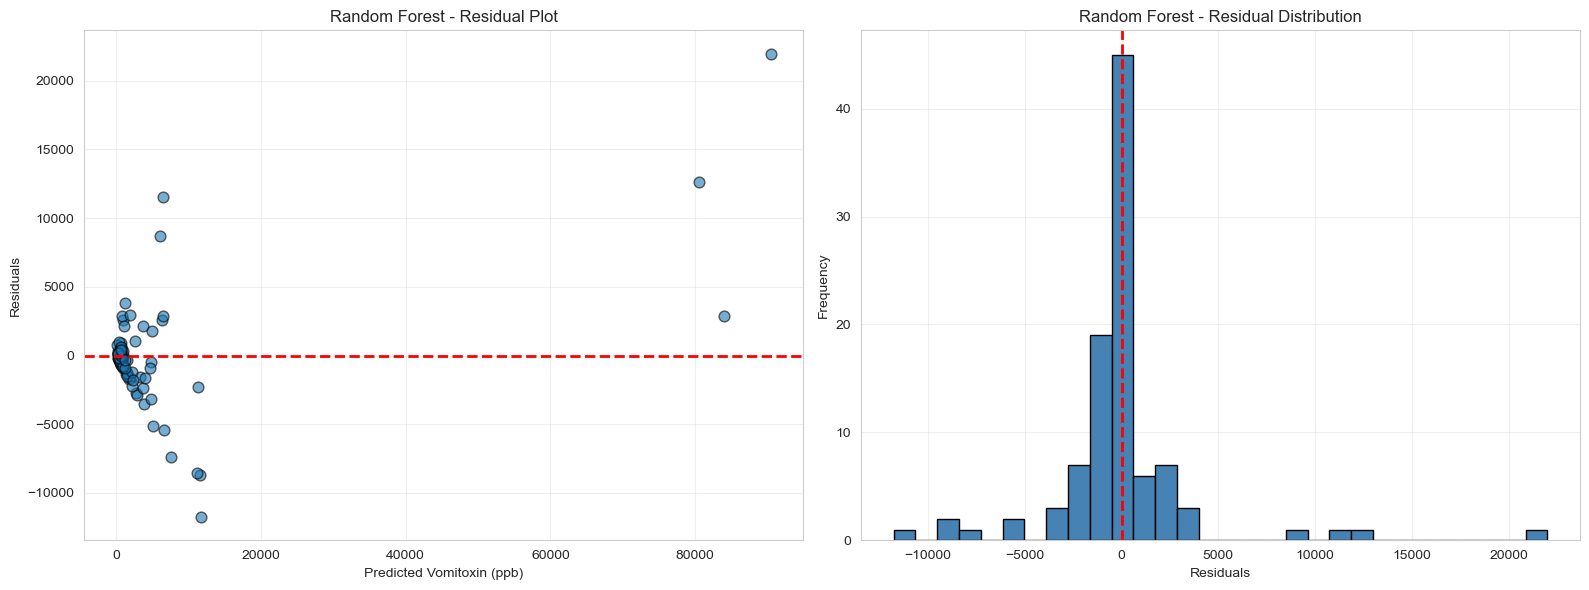

In [10]:
# Residuals for best model
residuals = y_test - y_test_pred_best

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residual plot
axes[0].scatter(y_test_pred_best, residuals, alpha=0.6, edgecolors='black', s=60)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Vomitoxin (ppb)')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'{best_model_name} - Residual Plot')
axes[0].grid(alpha=0.3)

# Residual distribution
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'{best_model_name} - Residual Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/best_model_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. All Models Prediction Comparison

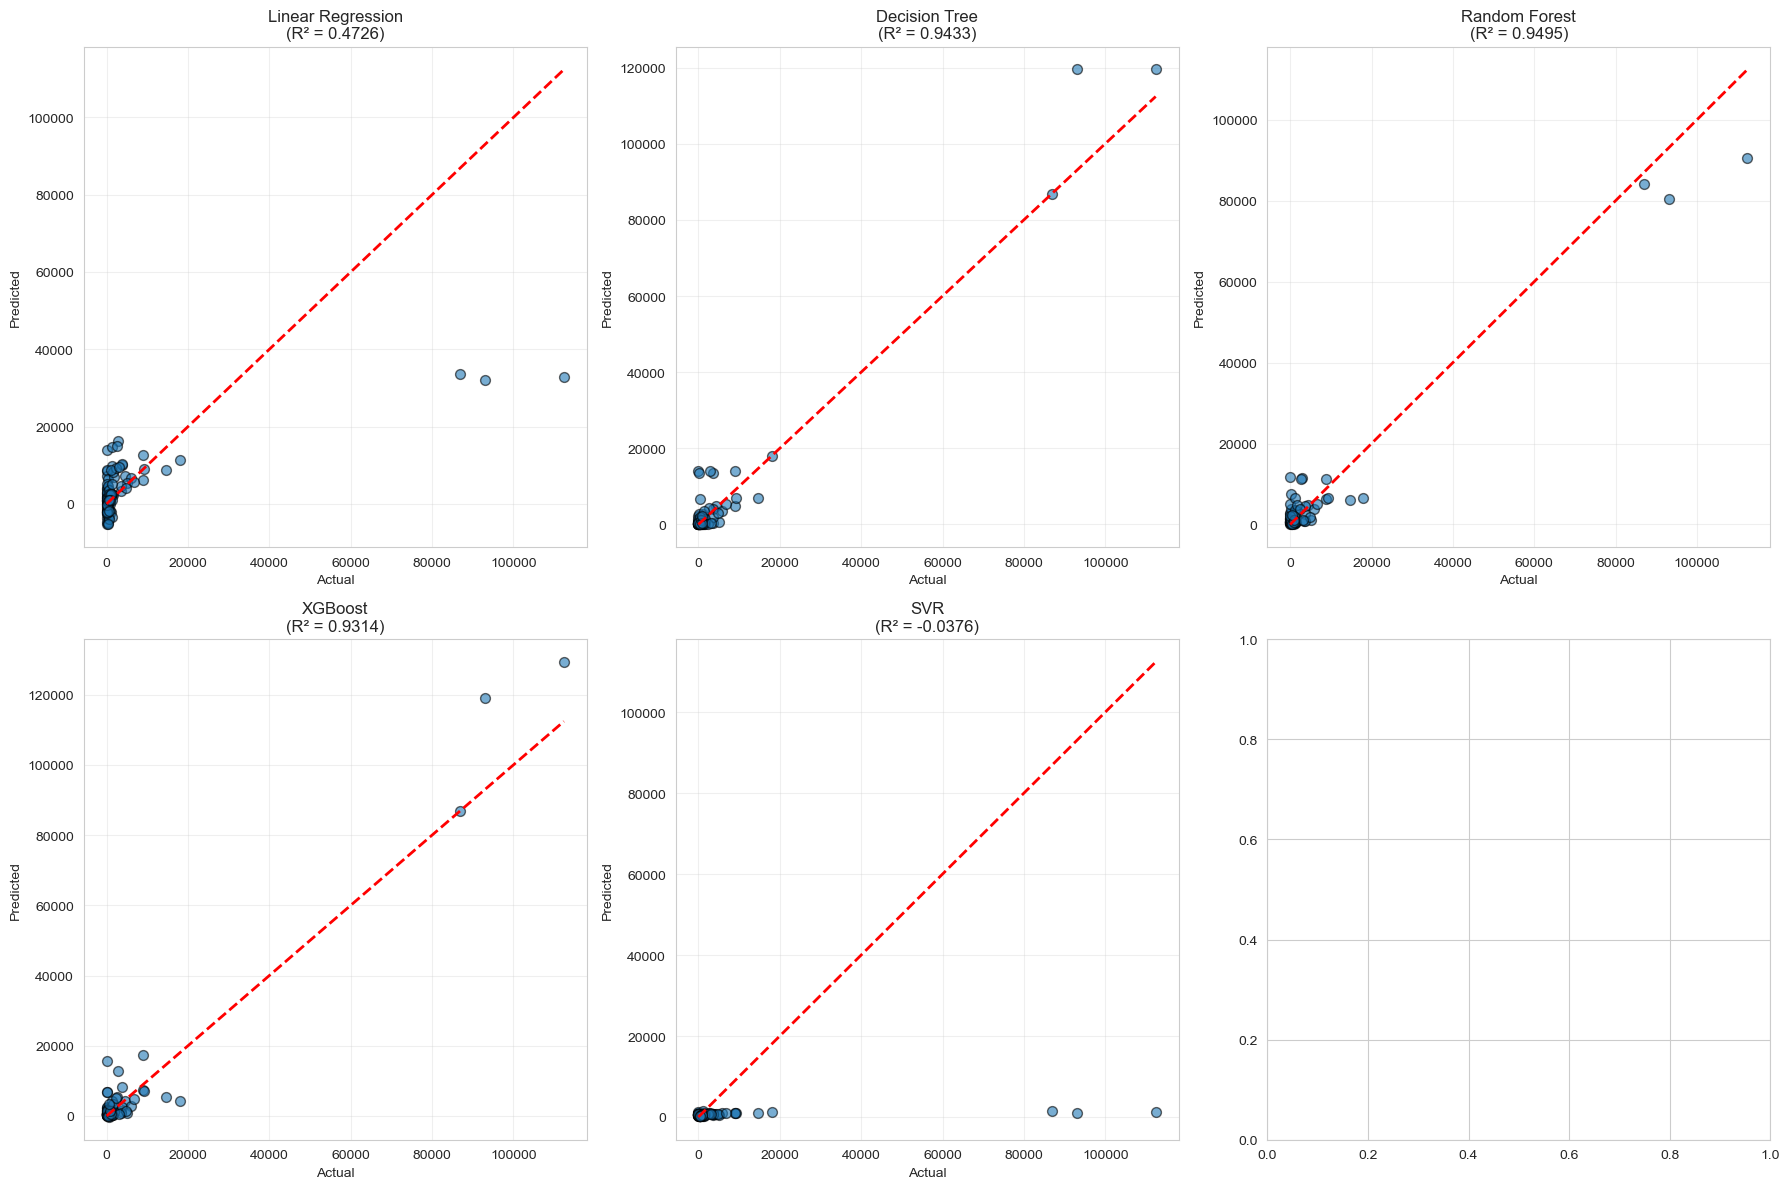

In [11]:
# Compare all model predictions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, preds) in enumerate(predictions.items()):
    y_pred = preds['test']
    r2 = r2_score(y_test, y_pred)
    
    axes[i].scatter(y_test, y_pred, alpha=0.6, edgecolors='black', s=50)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                 'r--', linewidth=2)
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
    axes[i].set_title(f'{name}\n(R² = {r2:.4f})')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/all_models_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Save Results

In [12]:
# Save results to CSV
results_df.to_csv('../outputs/model_results.csv', index=False)
print("✓ Results saved to model_results.csv")

# Save best model using pickle
import pickle
best_model = models[best_model_name]
with open(f'../models/best_model_{best_model_name.replace(" ", "_").lower()}.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"✓ Best model ({best_model_name}) saved!")

✓ Results saved to model_results.csv
✓ Best model (Random Forest) saved!


## 11. Model Ranking

In [13]:
# Rank models by different metrics
print("="*60)
print("MODEL RANKINGS")
print("="*60)

print("\nBy R² Score (Test):")
for i, row in results_df.sort_values('Test_R2', ascending=False).iterrows():
    print(f"  {row['Model']:20s} - {row['Test_R2']:.4f}")

print("\nBy RMSE (Test):")
for i, row in results_df.sort_values('Test_RMSE').iterrows():
    print(f"  {row['Model']:20s} - {row['Test_RMSE']:.2f}")

print("\nBy MAE (Test):")
for i, row in results_df.sort_values('Test_MAE').iterrows():
    print(f"  {row['Model']:20s} - {row['Test_MAE']:.2f}")

print("="*60)

MODEL RANKINGS

By R² Score (Test):
  Random Forest        - 0.9495
  Decision Tree        - 0.9433
  XGBoost              - 0.9314
  Linear Regression    - 0.4726
  SVR                  - -0.0376

By RMSE (Test):
  Random Forest        - 3758.31
  Decision Tree        - 3980.12
  XGBoost              - 4380.58
  Linear Regression    - 12141.97
  SVR                  - 17031.07

By MAE (Test):
  Decision Tree        - 1688.03
  Random Forest        - 1869.78
  XGBoost              - 1996.28
  SVR                  - 4170.64
  Linear Regression    - 4918.13


## 12. Summary

In [14]:
print("="*60)
print("NOTEBOOK 4: TRADITIONAL ML MODELS - COMPLETED")
print("="*60)
print(f"\n✓ Models trained: {len(models)}")
print(f"✓ Best model: {best_model_name}")
print(f"✓ Best Test R²: {best_r2:.4f}")
print(f"✓ Best Test RMSE: {results_df.iloc[0]['Test_RMSE']:.2f}")
print(f"✓ Best Test MAE: {results_df.iloc[0]['Test_MAE']:.2f}")
print("\n✓ Results saved to CSV")
print("✓ Best model saved")
print("✓ Visualizations saved: 5 plots")
print("\n" + "="*60)
print("Ready for Notebook 5: Final Evaluation & Insights")
print("="*60)

NOTEBOOK 4: TRADITIONAL ML MODELS - COMPLETED

✓ Models trained: 5
✓ Best model: Random Forest
✓ Best Test R²: 0.9495
✓ Best Test RMSE: 3758.31
✓ Best Test MAE: 1869.78

✓ Results saved to CSV
✓ Best model saved
✓ Visualizations saved: 5 plots

Ready for Notebook 5: Final Evaluation & Insights
